In [65]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [66]:
X,y = make_regression(n_samples=150, n_features=1, n_informative=1, n_targets=1, noise=50, random_state=42)

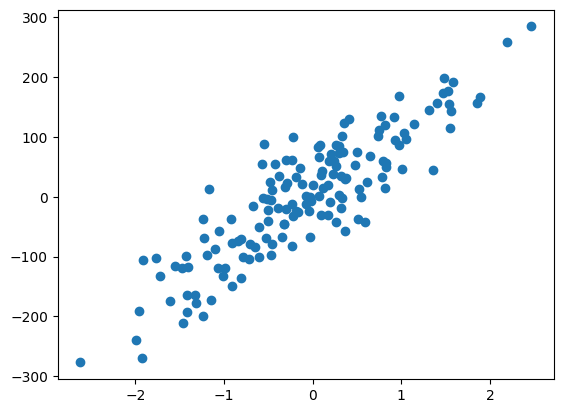

In [67]:
plt.scatter(X,y)

In [68]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [69]:
from sklearn.linear_model import LinearRegression

In [70]:
lr = LinearRegression()

In [71]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [72]:
lr.coef_

array([96.83843756])

In [73]:
lr.intercept_

np.float64(6.902272376806861)

In [74]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7417189360874232

In [75]:
from PIL import Image
gd_eq1 = Image.open("gd_eq1.png")
gd_eq2 = Image.open("gd_eq2.png")
gd_eq3 = Image.open("gd_eq3.png")

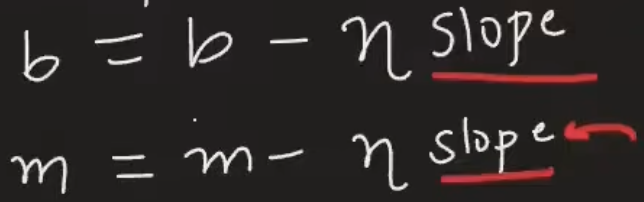

In [76]:
gd_eq1

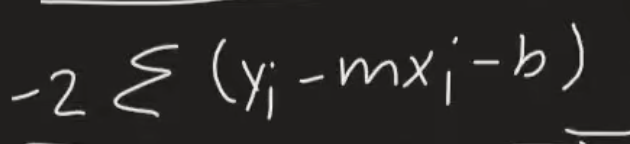

In [77]:
gd_eq2

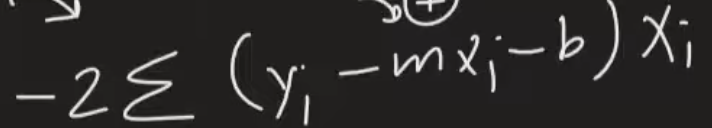

In [78]:
gd_eq3

In [79]:
class GDRegressor:
    def __init__(self,learning_rate,epochs):
        self.m = 100
        self.b = -200
        self.lr = learning_rate
        self.ep = epochs

    def fit(self,X,y):
        for i in range(self.ep):
            loss_slope_b = -2 * np.sum(y - self.m * X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m * X.ravel() - self.b)*X.ravel())

            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
            print(self.m,self.b)

    def predict(self,X):
            return self.m * X + self.b

In [80]:
gd = GDRegressor(0.001,100)

In [81]:
gd.fit(X_train,y_train)

95.18168034181939 -150.28094960878389
92.45551202796699 -112.58973091042955
91.1020820135035 -83.99830185028982
90.62547646381717 -62.295573474648116
90.68765621825199 -45.81092254127095
91.06142841882517 -33.28135851984289
91.59687035308622 -23.751500277050525
92.19746011552078 -16.498222167763387
92.80319182846858 -10.973856968186695
93.37870068259248 -6.763363922113637
93.90496842759956 -3.5520112275250075
94.37357720966381 -1.1009787112966891
94.78276853434315 0.7710705346958704
95.13477380177413 2.201917794674211
95.43403471392583 3.2963209600847048
95.6860415745447 4.133983842182911
95.89659657145778 4.775589882445395
96.07136594164497 5.267373207356832
96.21562560030229 5.644583776219767
96.3341338338206 5.934115864501678
96.43108526509778 6.1565031942814405
96.51011486048516 6.327434323269298
96.57433097401083 6.458904419680547
96.62636355565591 6.560091264433576
96.66841858076819 6.638021965912189
96.7023331308152 6.698080739270511
96.72962783333554 6.744395907667441
96.751554

In [87]:
#Above we can see it going towards minima
#Same result as sklearn, i.e. coef = 96.83 and intercept = 6.9
#Same r2 score as sklearn class with our class

In [83]:
y_pred = gd.predict(X_test)
r2_score(y_test,y_pred)

0.7417189360803764